## Problem definition and Model outcome

# Getting the Dataset

In [17]:
from google.colab import drive
drive.mount('/content/drive')
!unzip -q "/content/drive/MyDrive/Mastitis Disease v3.zip"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
replace Mastitis Disease v3/Healthy Udder/00000009_jpg.rf.a4ec5902fba86a3cafad1abd2f469f41.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


## Libraries

In [18]:
# Data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob as gb
from tqdm.auto import tqdm

# PyTorch libraries for deep learning
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, RandomSampler
from torchvision import datasets, transforms
from PIL import Image

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Visualize and Analyze
   - Check for:
     - Image size consistency
     - Need for augmentation
     - Class imbalances

In [19]:
# Define the path to the dataset
Images_Path="/content/Mastitis Disease v3"
print("Classes:", os.listdir(Images_Path))


Classes: ['Infected Udder', 'Healthy Udder']


In [20]:
# Function to count the number of images in each class
def count_image_df(path):
    df = pd.DataFrame(columns=["Class", "Count"])
    for folder in os.listdir(path):
        folder_path = os.path.join(path, folder)  # Join the path correctly
        if os.path.isdir(folder_path):  # Ensure it is a directory
            files = gb.glob(os.path.join(folder_path, "*.jpg"))  # Correct file pattern
            df.loc[len(df.index)] = [folder, len(files)]
    return df

# Update the path with your dataset directory
Images_Path= "/content/Mastitis Disease v3"
# Generate counts for each class
count_image = count_image_df(Images_Path)
count_image


,Class,Count
0,Infected Udder,1698
1,Healthy Udder,805


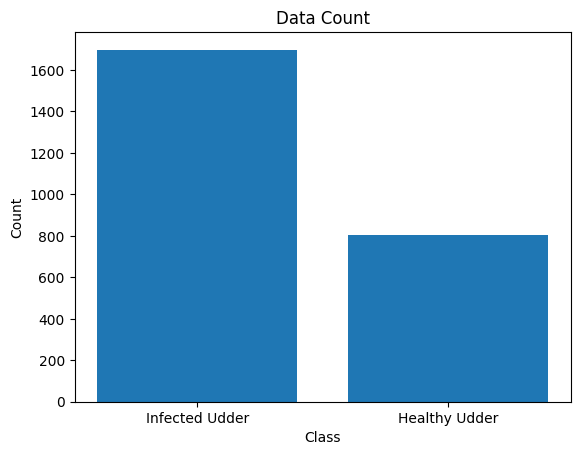

In [21]:
# Plot the data distribution
plt.bar(count_image["Class"], count_image["Count"])
plt.title("Data Count")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [22]:
# Function to get the image sizes and check for consistency
def get_image_size(path, is_pred=False):
    size = []

    # Adjust folders based on prediction mode
    if is_pred:
        folders = [""]
    else:
        folders = os.listdir(path)

    for folder in tqdm(folders):
        folder_path = os.path.join(path, folder)  # Properly construct the folder path
        if os.path.isdir(folder_path):  # Ensure the folder is a directory
            for img in gb.glob(os.path.join(folder_path, "*.jpg")):  # Correct file matching
                image = plt.imread(img)
                size.append(image.shape)  # Get the image shape
    return pd.Series(size).value_counts()

# Analyze image sizes
image_sizes = get_image_size(Images_Path)
image_sizes



  0%|          | 0/2 [00:00<?, ?it/s]

,count
"(640, 640, 3)",1211
"(256, 256, 3)",1122
"(284, 400, 3)",167
"(209, 240, 3)",1
"(284, 332, 3)",1
"(284, 356, 3)",1


# Make Transformations Based on Analysis

In [23]:
# Apply transformations to the images
input_size = 224
train_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),  # Resize images
    transforms.ToTensor(),   # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])   # Normalize
])

test_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

' transforms.RandomHorizontalFlip(),  # Apply random horizontal flip\n    transforms.RandomRotation(10),   # Apply random rotations\n    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),   # Adjust color'

# Split Dataset
   - Split into Training, Validation, and Test sets
   - Prepare DataLoaders

In [24]:
# Split dataset into training, validation, and test sets
dataset = datasets.ImageFolder(Images_Path, transform=train_transforms)

In [25]:
class_names = dataset.classes
print(class_names)

['Healthy Udder', 'Infected Udder']


# Build Model Architecture
   - Show the summary of the model
   - Define loss function

In [26]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import numpy as np
from PIL import Image
from tempfile import TemporaryDirectory
import torch.backends.cudnn as cudnn

# Enable benchmarking for better performance
cudnn.benchmark = True

# Display plots inline
plt.ion()

In [27]:
num_classes = 2
num_epochs = 10
learning_rate = 0.00002

In [28]:
# Load pre-trained EfficientNet
model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

In [29]:
# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [30]:
# optimizer, and learning rate scheduler
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [31]:
from torchsummary import summary
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2d-14         [-1, 16, 1

# Training Loop
   - Train on Training data
   - Show and evaluate on Validation data

In [32]:
# Define ratios for splitting
train_ratio = 0.8
test_ratio = 0.2

# Calculate sizes for splits
dataset_size = len(dataset)
train_size = int(train_ratio * dataset_size)
test_size = dataset_size - train_size

# Split the dataset
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])


# Display dataset details
print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 2008
Test set size: 502



======== Fold 0 ========

Epoch 1/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.2303 │
├───────────┼─────────┤
│ Accuracy  │  0.9064 │
├───────────┼─────────┤
│ Precision │  0.8854 │
├───────────┼─────────┤
│ Recall    │  0.9082 │
├───────────┼─────────┤
│ F1 Score  │  0.895  │
╘═══════════╧═════════╛

Epoch 2/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.1066 │
├───────────┼─────────┤
│ Accuracy  │  0.9612 │
├───────────┼─────────┤
│ Precision │  0.9501 │
├───────────┼─────────┤
│ Recall    │  0.9618 │
├───────────┼─────────┤
│ F1 Score  │  0.9556 │
╘═══════════╧═════════╛

Epoch 3/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.1199 │
├───────────┼─────────┤
│ Accuracy  │  0.9567 │
├───────────┼─────────┤
│ Precision │  0.945  │
├───────────┼─────────┤
│ Recall    │  0.9569 │
├───────────┼─────────┤
│ F1 Score  │  0.9505 │
╘═══════════╧═════════╛

Epoch 4/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0658 │
├───────────┼─────────┤
│ Accuracy  │  0.9756 │
├───────────┼─────────┤
│ Precision │  0.9678 │
├───────────┼─────────┤
│ Recall    │  0.9766 │
├───────────┼─────────┤
│ F1 Score  │  0.972  │
╘═══════════╧═════════╛

Epoch 5/10


...

╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0346 │
├───────────┼─────────┤
│ Accuracy  │  0.9875 │
├───────────┼─────────┤
│ Precision │  0.9824 │
├───────────┼─────────┤
│ Recall    │  0.9892 │
├───────────┼─────────┤
│ F1 Score  │  0.9857 │
╘═══════════╧═════════╛

Epoch 7/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0089 │
├───────────┼─────────┤
│ Accuracy  │  0.9975 │
├───────────┼─────────┤
│ Precision │  0.9969 │
├───────────┼─────────┤
│ Recall    │  0.9973 │
├───────────┼─────────┤
│ F1 Score  │  0.9971 │
╘═══════════╧═════════╛

Epoch 8/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0155 │
├───────────┼─────────┤
│ Accuracy  │  0.9955 │
├───────────┼─────────┤
│ Precision │  0.9946 │
├───────────┼─────────┤
│ Recall    │  0.995  │
├───────────┼─────────┤
│ F1 Score  │  0.9948 │
╘═══════════╧═════════╛

Epoch 9/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0059 │
├───────────┼─────────┤
│ Accuracy  │  0.9975 │
├───────────┼─────────┤
│ Precision │  0.9965 │
├───────────┼─────────┤
│ Recall    │  0.9978 │
├───────────┼─────────┤
│ F1 Score  │  0.9971 │
╘═══════════╧═════════╛

Epoch 10/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0031 │
├───────────┼─────────┤
│ Accuracy  │  0.9995 │
├───────────┼─────────┤
│ Precision │  0.9996 │
├───────────┼─────────┤
│ Recall    │  0.9992 │
├───────────┼─────────┤
│ F1 Score  │  0.9994 │
╘═══════════╧═════════╛

Evaluating on test set...
╒═══════════╤════════╕
│ Metric    │   Test │
╞═══════════╪════════╡
│ Loss      │ 0.0268 │
├───────────┼────────┤
│ Accuracy  │ 0.992  │
├───────────┼────────┤
│ Precision │ 0.9911 │
├───────────┼────────┤
│ Recall    │ 0.9911 │
├───────────┼────────┤
│ F1 Score  │ 0.9911 │
╘═══════════╧════════╛

Classification Report:
                precision    recall  f1-score   support

 Healthy Udder       0.99      0.99      0.99       171
Infected Udder       0.99      0.99      0.99       331

      accuracy                           0.99       502
     macro avg       0.99      0.99      0.99       502
  weighted avg       0.99      0.99      0.99       502


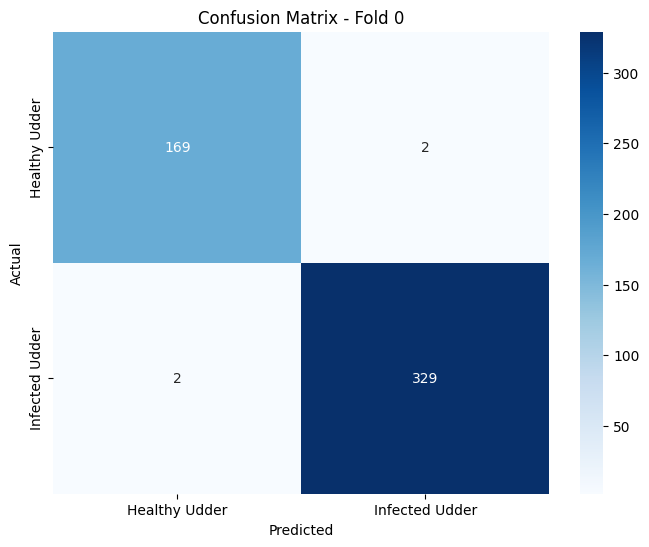


======== Fold 1 ========

Epoch 1/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0593 │
├───────────┼─────────┤
│ Accuracy  │  0.9856 │
├───────────┼─────────┤
│ Precision │  0.9818 │
├───────────┼─────────┤
│ Recall    │  0.9853 │
├───────────┼─────────┤
│ F1 Score  │  0.9835 │
╘═══════════╧═════════╛

Epoch 2/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0348 │
├───────────┼─────────┤
│ Accuracy  │  0.9875 │
├───────────┼─────────┤
│ Precision │  0.984  │
├───────────┼─────────┤
│ Recall    │  0.9876 │
├───────────┼─────────┤
│ F1 Score  │  0.9858 │
╘═══════════╧═════════╛

Epoch 3/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0479 │
├───────────┼─────────┤
│ Accuracy  │  0.9846 │
├───────────┼─────────┤
│ Precision │  0.9803 │
├───────────┼─────────┤
│ Recall    │  0.9845 │
├───────────┼─────────┤
│ F1 Score  │  0.9824 │
╘═══════════╧═════════╛

Epoch 4/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0385 │
├───────────┼─────────┤
│ Accuracy  │  0.9841 │
├───────────┼─────────┤
│ Precision │  0.9792 │
├───────────┼─────────┤
│ Recall    │  0.9846 │
├───────────┼─────────┤
│ F1 Score  │  0.9818 │
╘═══════════╧═════════╛

Epoch 5/10


...

╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0205 │
├───────────┼─────────┤
│ Accuracy  │  0.992  │
├───────────┼─────────┤
│ Precision │  0.9897 │
├───────────┼─────────┤
│ Recall    │  0.9921 │
├───────────┼─────────┤
│ F1 Score  │  0.9909 │
╘═══════════╧═════════╛

Epoch 7/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0093 │
├───────────┼─────────┤
│ Accuracy  │  0.9975 │
├───────────┼─────────┤
│ Precision │  0.9969 │
├───────────┼─────────┤
│ Recall    │  0.9973 │
├───────────┼─────────┤
│ F1 Score  │  0.9971 │
╘═══════════╧═════════╛

Epoch 8/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0058 │
├───────────┼─────────┤
│ Accuracy  │  0.9975 │
├───────────┼─────────┤
│ Precision │  0.9965 │
├───────────┼─────────┤
│ Recall    │  0.9978 │
├───────────┼─────────┤
│ F1 Score  │  0.9971 │
╘═══════════╧═════════╛

Epoch 9/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0105 │
├───────────┼─────────┤
│ Accuracy  │  0.998  │
├───────────┼─────────┤
│ Precision │  0.9977 │
├───────────┼─────────┤
│ Recall    │  0.9977 │
├───────────┼─────────┤
│ F1 Score  │  0.9977 │
╘═══════════╧═════════╛

Epoch 10/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0053 │
├───────────┼─────────┤
│ Accuracy  │  0.998  │
├───────────┼─────────┤
│ Precision │  0.9969 │
├───────────┼─────────┤
│ Recall    │  0.9985 │
├───────────┼─────────┤
│ F1 Score  │  0.9977 │
╘═══════════╧═════════╛

Evaluating on test set...
╒═══════════╤════════╕
│ Metric    │   Test │
╞═══════════╪════════╡
│ Loss      │ 0.0151 │
├───────────┼────────┤
│ Accuracy  │ 0.996  │
├───────────┼────────┤
│ Precision │ 0.9971 │
├───────────┼────────┤
│ Recall    │ 0.9938 │
├───────────┼────────┤
│ F1 Score  │ 0.9954 │
╘═══════════╧════════╛

Classification Report:
                precision    recall  f1-score   support

 Healthy Udder       1.00      0.99      0.99       161
Infected Udder       0.99      1.00      1.00       341

      accuracy                           1.00       502
     macro avg       1.00      0.99      1.00       502
  weighted avg       1.00      1.00      1.00       502


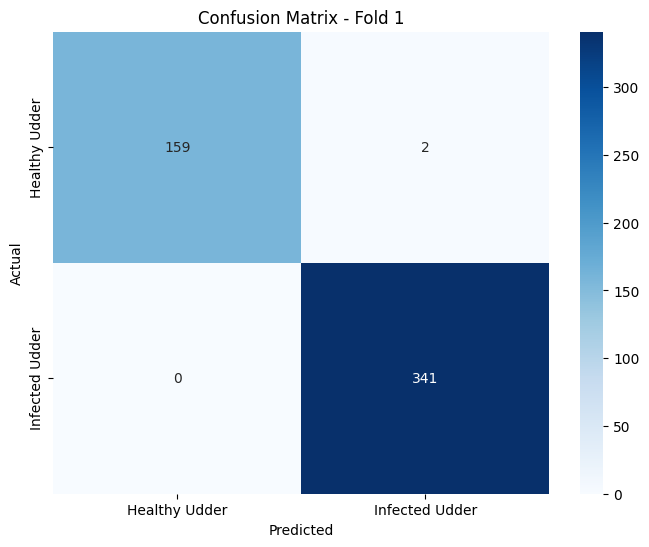


======== Fold 2 ========

Epoch 1/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0525 │
├───────────┼─────────┤
│ Accuracy  │  0.9866 │
├───────────┼─────────┤
│ Precision │  0.9829 │
├───────────┼─────────┤
│ Recall    │  0.9864 │
├───────────┼─────────┤
│ F1 Score  │  0.9846 │
╘═══════════╧═════════╛

Epoch 2/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.037  │
├───────────┼─────────┤
│ Accuracy  │  0.9856 │
├───────────┼─────────┤
│ Precision │  0.9817 │
├───────────┼─────────┤
│ Recall    │  0.9853 │
├───────────┼─────────┤
│ F1 Score  │  0.9835 │
╘═══════════╧═════════╛

Epoch 3/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0397 │
├───────────┼─────────┤
│ Accuracy  │  0.9866 │
├───────────┼─────────┤
│ Precision │  0.9825 │
├───────────┼─────────┤
│ Recall    │  0.9868 │
├───────────┼─────────┤
│ F1 Score  │  0.9846 │
╘═══════════╧═════════╛

Epoch 4/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0339 │
├───────────┼─────────┤
│ Accuracy  │  0.9871 │
├───────────┼─────────┤
│ Precision │  0.9847 │
├───────────┼─────────┤
│ Recall    │  0.9855 │
├───────────┼─────────┤
│ F1 Score  │  0.9851 │
╘═══════════╧═════════╛

Epoch 5/10


...

╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0072 │
├───────────┼─────────┤
│ Accuracy  │  0.9995 │
├───────────┼─────────┤
│ Precision │  0.9992 │
├───────────┼─────────┤
│ Recall    │  0.9996 │
├───────────┼─────────┤
│ F1 Score  │  0.9994 │
╘═══════════╧═════════╛

Epoch 7/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.005  │
├───────────┼─────────┤
│ Accuracy  │  0.9985 │
├───────────┼─────────┤
│ Precision │  0.9985 │
├───────────┼─────────┤
│ Recall    │  0.9981 │
├───────────┼─────────┤
│ F1 Score  │  0.9983 │
╘═══════════╧═════════╛

Epoch 8/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0028 │
├───────────┼─────────┤
│ Accuracy  │  0.999  │
├───────────┼─────────┤
│ Precision │  0.9984 │
├───────────┼─────────┤
│ Recall    │  0.9993 │
├───────────┼─────────┤
│ F1 Score  │  0.9989 │
╘═══════════╧═════════╛

Epoch 9/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0116 │
├───────────┼─────────┤
│ Accuracy  │  0.9955 │
├───────────┼─────────┤
│ Precision │  0.9943 │
├───────────┼─────────┤
│ Recall    │  0.9955 │
├───────────┼─────────┤
│ F1 Score  │  0.9949 │
╘═══════════╧═════════╛

Epoch 10/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0101 │
├───────────┼─────────┤
│ Accuracy  │  0.9965 │
├───────────┼─────────┤
│ Precision │  0.9954 │
├───────────┼─────────┤
│ Recall    │  0.9966 │
├───────────┼─────────┤
│ F1 Score  │  0.996  │
╘═══════════╧═════════╛

Evaluating on test set...
╒═══════════╤════════╕
│ Metric    │   Test │
╞═══════════╪════════╡
│ Loss      │ 0.0095 │
├───────────┼────────┤
│ Accuracy  │ 0.996  │
├───────────┼────────┤
│ Precision │ 0.9939 │
├───────────┼────────┤
│ Recall    │ 0.9971 │
├───────────┼────────┤
│ F1 Score  │ 0.9955 │
╘═══════════╧════════╛

Classification Report:
                precision    recall  f1-score   support

 Healthy Udder       0.99      1.00      0.99       162
Infected Udder       1.00      0.99      1.00       340

      accuracy                           1.00       502
     macro avg       0.99      1.00      1.00       502
  weighted avg       1.00      1.00      1.00       502


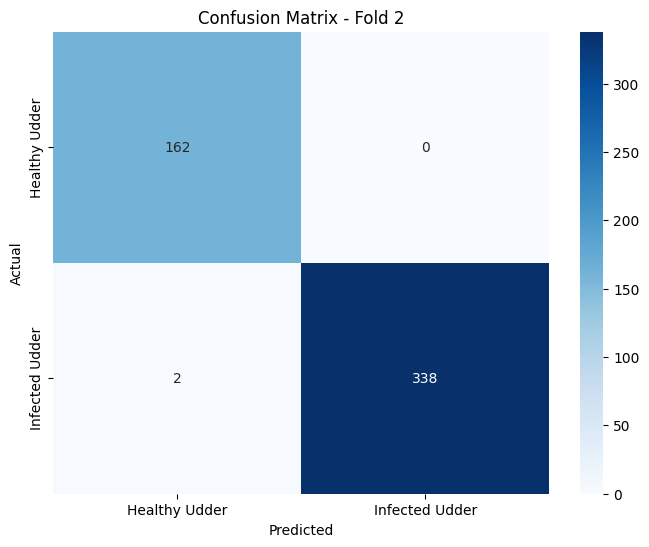


======== Fold 3 ========

Epoch 1/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0382 │
├───────────┼─────────┤
│ Accuracy  │  0.9905 │
├───────────┼─────────┤
│ Precision │  0.9878 │
├───────────┼─────────┤
│ Recall    │  0.9906 │
├───────────┼─────────┤
│ F1 Score  │  0.9892 │
╘═══════════╧═════════╛

Epoch 2/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0281 │
├───────────┼─────────┤
│ Accuracy  │  0.9935 │
├───────────┼─────────┤
│ Precision │  0.9924 │
├───────────┼─────────┤
│ Recall    │  0.9928 │
├───────────┼─────────┤
│ F1 Score  │  0.9926 │
╘═══════════╧═════════╛

Epoch 3/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0125 │
├───────────┼─────────┤
│ Accuracy  │  0.995  │
├───────────┼─────────┤
│ Precision │  0.9939 │
├───────────┼─────────┤
│ Recall    │  0.9947 │
├───────────┼─────────┤
│ F1 Score  │  0.9943 │
╘═══════════╧═════════╛

Epoch 4/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0461 │
├───────────┼─────────┤
│ Accuracy  │  0.9866 │
├───────────┼─────────┤
│ Precision │  0.9825 │
├───────────┼─────────┤
│ Recall    │  0.9868 │
├───────────┼─────────┤
│ F1 Score  │  0.9846 │
╘═══════════╧═════════╛

Epoch 5/10


...

╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0071 │
├───────────┼─────────┤
│ Accuracy  │  0.998  │
├───────────┼─────────┤
│ Precision │  0.9977 │
├───────────┼─────────┤
│ Recall    │  0.9977 │
├───────────┼─────────┤
│ F1 Score  │  0.9977 │
╘═══════════╧═════════╛

Epoch 7/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0025 │
├───────────┼─────────┤
│ Accuracy  │  1      │
├───────────┼─────────┤
│ Precision │  1      │
├───────────┼─────────┤
│ Recall    │  1      │
├───────────┼─────────┤
│ F1 Score  │  1      │
╘═══════════╧═════════╛

Epoch 8/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0006 │
├───────────┼─────────┤
│ Accuracy  │  1      │
├───────────┼─────────┤
│ Precision │  1      │
├───────────┼─────────┤
│ Recall    │  1      │
├───────────┼─────────┤
│ F1 Score  │  1      │
╘═══════════╧═════════╛

Epoch 9/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0016 │
├───────────┼─────────┤
│ Accuracy  │  0.9995 │
├───────────┼─────────┤
│ Precision │  0.9992 │
├───────────┼─────────┤
│ Recall    │  0.9996 │
├───────────┼─────────┤
│ F1 Score  │  0.9994 │
╘═══════════╧═════════╛

Epoch 10/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0053 │
├───────────┼─────────┤
│ Accuracy  │  0.998  │
├───────────┼─────────┤
│ Precision │  0.9973 │
├───────────┼─────────┤
│ Recall    │  0.9981 │
├───────────┼─────────┤
│ F1 Score  │  0.9977 │
╘═══════════╧═════════╛

Evaluating on test set...
╒═══════════╤════════╕
│ Metric    │   Test │
╞═══════════╪════════╡
│ Loss      │ 0.0011 │
├───────────┼────────┤
│ Accuracy  │ 1      │
├───────────┼────────┤
│ Precision │ 1      │
├───────────┼────────┤
│ Recall    │ 1      │
├───────────┼────────┤
│ F1 Score  │ 1      │
╘═══════════╧════════╛

Classification Report:
                precision    recall  f1-score   support

 Healthy Udder       1.00      1.00      1.00       161
Infected Udder       1.00      1.00      1.00       341

      accuracy                           1.00       502
     macro avg       1.00      1.00      1.00       502
  weighted avg       1.00      1.00      1.00       502


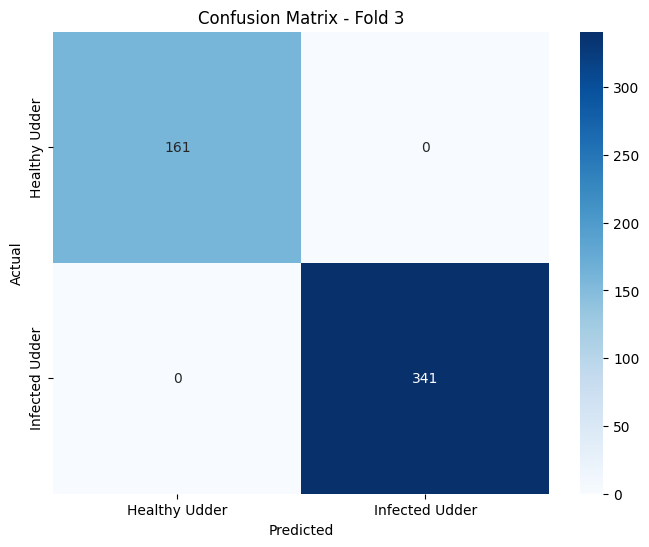


======== Fold 4 ========

Epoch 1/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0379 │
├───────────┼─────────┤
│ Accuracy  │  0.9905 │
├───────────┼─────────┤
│ Precision │  0.9883 │
├───────────┼─────────┤
│ Recall    │  0.9902 │
├───────────┼─────────┤
│ F1 Score  │  0.9893 │
╘═══════════╧═════════╛

Epoch 2/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.019  │
├───────────┼─────────┤
│ Accuracy  │  0.994  │
├───────────┼─────────┤
│ Precision │  0.9932 │
├───────────┼─────────┤
│ Recall    │  0.9932 │
├───────────┼─────────┤
│ F1 Score  │  0.9932 │
╘═══════════╧═════════╛

Epoch 3/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0114 │
├───────────┼─────────┤
│ Accuracy  │  0.997  │
├───────────┼─────────┤
│ Precision │  0.9958 │
├───────────┼─────────┤
│ Recall    │  0.9974 │
├───────────┼─────────┤
│ F1 Score  │  0.9966 │
╘═══════════╧═════════╛

Epoch 4/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0059 │
├───────────┼─────────┤
│ Accuracy  │  0.997  │
├───────────┼─────────┤
│ Precision │  0.9966 │
├───────────┼─────────┤
│ Recall    │  0.9966 │
├───────────┼─────────┤
│ F1 Score  │  0.9966 │
╘═══════════╧═════════╛

Epoch 5/10


...

╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0253 │
├───────────┼─────────┤
│ Accuracy  │  0.991  │
├───────────┼─────────┤
│ Precision │  0.9887 │
├───────────┼─────────┤
│ Recall    │  0.991  │
├───────────┼─────────┤
│ F1 Score  │  0.9898 │
╘═══════════╧═════════╛

Epoch 7/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.004  │
├───────────┼─────────┤
│ Accuracy  │  0.9995 │
├───────────┼─────────┤
│ Precision │  0.9992 │
├───────────┼─────────┤
│ Recall    │  0.9996 │
├───────────┼─────────┤
│ F1 Score  │  0.9994 │
╘═══════════╧═════════╛

Epoch 8/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0023 │
├───────────┼─────────┤
│ Accuracy  │  0.9995 │
├───────────┼─────────┤
│ Precision │  0.9996 │
├───────────┼─────────┤
│ Recall    │  0.9992 │
├───────────┼─────────┤
│ F1 Score  │  0.9994 │
╘═══════════╧═════════╛

Epoch 9/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0014 │
├───────────┼─────────┤
│ Accuracy  │  1      │
├───────────┼─────────┤
│ Precision │  1      │
├───────────┼─────────┤
│ Recall    │  1      │
├───────────┼─────────┤
│ F1 Score  │  1      │
╘═══════════╧═════════╛

Epoch 10/10


╒═══════════╤═════════╕
│ Metric    │   Train │
╞═══════════╪═════════╡
│ Loss      │  0.0049 │
├───────────┼─────────┤
│ Accuracy  │  0.998  │
├───────────┼─────────┤
│ Precision │  0.9977 │
├───────────┼─────────┤
│ Recall    │  0.9977 │
├───────────┼─────────┤
│ F1 Score  │  0.9977 │
╘═══════════╧═════════╛

Evaluating on test set...
╒═══════════╤════════╕
│ Metric    │   Test │
╞═══════════╪════════╡
│ Loss      │ 0.0019 │
├───────────┼────────┤
│ Accuracy  │ 1      │
├───────────┼────────┤
│ Precision │ 1      │
├───────────┼────────┤
│ Recall    │ 1      │
├───────────┼────────┤
│ F1 Score  │ 1      │
╘═══════════╧════════╛

Classification Report:
                precision    recall  f1-score   support

 Healthy Udder       1.00      1.00      1.00       150
Infected Udder       1.00      1.00      1.00       352

      accuracy                           1.00       502
     macro avg       1.00      1.00      1.00       502
  weighted avg       1.00      1.00      1.00       502


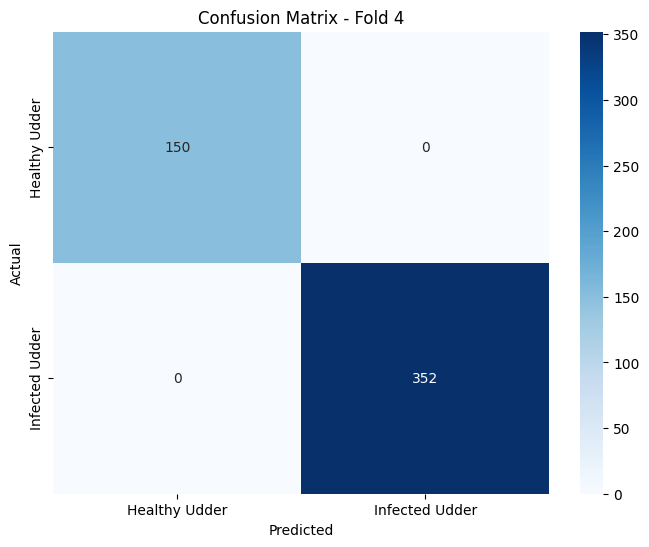


======= K-FOLD CROSS VALIDATION RESULTS =======
Fold 0: 99.20%
Fold 1: 99.60%
Fold 2: 99.60%
Fold 3: 100.00%
Fold 4: 100.00%

Average Accuracy: 99.68%


In [33]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm
from tabulate import tabulate
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

# ====== Class weight function ======
def calculate_class_weights(dataloader, num_classes, device):
    class_counts = Counter()

    for _, labels in dataloader:
        class_counts.update(labels.cpu().numpy())

    total_samples = sum(class_counts.values())
    weights = [1.0 / class_counts[i] if i in class_counts else 0 for i in range(num_classes)]
    weights = torch.tensor(weights, dtype=torch.float, device=device)

    return weights

# Hyperparameters
batch_size = 32
splits = 5
num_epochs = 10



# Combine dataset if it's split
dataset = ConcatDataset([train_dataset, test_dataset])

# K-Fold setup
kfold = KFold(n_splits=splits, shuffle=True)
results = {}

# K-Fold loop
for fold, (train_idx, test_idx) in enumerate(kfold.split(dataset)):
    print(f'\n======== Fold {fold} ========')

    train_subset = Subset(dataset, train_idx)
    test_subset = Subset(dataset, test_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

    # Calculate class weights for this fold
    class_weights = calculate_class_weights(train_loader, num_classes=len(class_names), device=device)


    model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        model.train()

        total_train_loss = 0
        correct_train = 0
        total_train = 0
        y_true_train, y_pred_train = [], []

        loop = tqdm(train_loader, desc=f"Training Fold {fold}", leave=False)
        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

            y_true_train.extend(labels.cpu().numpy())
            y_pred_train.extend(preds.cpu().numpy())
            loop.set_postfix(loss=loss.item())

        scheduler.step()

        train_loss = total_train_loss / total_train
        train_acc = correct_train / total_train
        train_precision = precision_score(y_true_train, y_pred_train, average='macro')
        train_recall = recall_score(y_true_train, y_pred_train, average='macro')
        train_f1 = f1_score(y_true_train, y_pred_train, average='macro')

        print(tabulate([
            ["Loss", f"{train_loss:.4f}"],
            ["Accuracy", f"{train_acc:.4f}"],
            ["Precision", f"{train_precision:.4f}"],
            ["Recall", f"{train_recall:.4f}"],
            ["F1 Score", f"{train_f1:.4f}"],
        ], headers=["Metric", "Train"], tablefmt="fancy_grid"))

    # Evaluation
    print("\nEvaluating on test set...")
    model.eval()
    test_loss = 0
    correct_test = 0
    total_test = 0
    y_true_test, y_pred_test = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            correct_test += (preds == labels).sum().item()
            total_test += labels.size(0)

            y_true_test.extend(labels.cpu().numpy())
            y_pred_test.extend(preds.cpu().numpy())

    acc = correct_test / total_test
    prec = precision_score(y_true_test, y_pred_test, average='macro')
    rec = recall_score(y_true_test, y_pred_test, average='macro')
    f1 = f1_score(y_true_test, y_pred_test, average='macro')

    results[fold] = acc

    print(tabulate([
        ["Loss", f"{test_loss / total_test:.4f}"],
        ["Accuracy", f"{acc:.4f}"],
        ["Precision", f"{prec:.4f}"],
        ["Recall", f"{rec:.4f}"],
        ["F1 Score", f"{f1:.4f}"],
    ], headers=["Metric", "Test"], tablefmt="fancy_grid"))

    print("\nClassification Report:")
    print(classification_report(y_true_test, y_pred_test, target_names=class_names))

    cm = confusion_matrix(y_true_test, y_pred_test)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.show()

    # Save model
    torch.save(model.state_dict(), f'./model_fold_{fold}.pth')

# Final results
print("\n======= K-FOLD CROSS VALIDATION RESULTS =======")
avg_acc = 0
for fold, acc in results.items():
    print(f"Fold {fold}: {acc * 100:.2f}%")
    avg_acc += acc
print(f"\nAverage Accuracy: {(avg_acc / splits) * 100:.2f}%")


# Make Predictions
   - Visualize results

In [37]:
def imshow_fixed_grid1(img, labels):
    """
    Displays an image with fixed grid size.

    Args:
        img (torch.Tensor): The input image tensor.
        labels (str): The label corresponding to the input image.
    """
    # Convert tensor to numpy array and adjust channel order
    npimg = img.numpy()
    npimg = np.transpose(npimg, (1, 2, 0))  # Change (C, H, W) to (H, W, C)

    # Reverse normalization to restore original color range
    npimg = npimg * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    npimg = np.clip(npimg, 0, 1)  # Clip values to valid range [0, 1]

    plt.imshow(npimg)
    plt.title(labels)
    plt.axis('off')
    plt.show()

In [38]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms

def visualize_all_test_images(model, test_loader, class_names, device="cuda" if torch.cuda.is_available() else "cpu"):
    """
    Visualizes the model's predictions for all images in the test_loader.

    Args:
        model (torch.nn.Module): The trained model.
        test_loader (torch.utils.data.DataLoader): The DataLoader for test images.
        class_names (list): List of class names corresponding to label indices.
        device (str): Device to use ('cuda' or 'cpu').
    """
    was_training = model.training
    model.eval()  # Set model to evaluation mode
    model.to(device)

    fig, axs = plt.subplots(nrows=4, ncols=9, figsize=(16, 9))  # Adjust grid size as needed
    axs = axs.flatten()

    with torch.no_grad():
        index = 0
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            # Get predictions
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            # Move images back to CPU for visualization
            images = images.cpu()
            labels = labels.cpu()
            preds = preds.cpu()

            for i in range(images.shape[0]):
                if index >= len(axs):  # Stop if all subplots are filled
                    break

                npimg = images[i].permute(1, 2, 0).numpy()  # Convert tensor to image

                # Reverse normalization (adjust if different normalization was used)
                npimg = npimg * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
                npimg = np.clip(npimg, 0, 1)  # Clip values to valid range [0, 1]

                axs[index].imshow(npimg)
                axs[index].axis("off")

                pred_label = class_names[preds[i].item()]
                true_label = class_names[labels[i].item()]
                title_text = f"Pred: {pred_label}\nTrue: {true_label}".title()

                # Change title color based on correctness
                title_color = "green" if pred_label == true_label else "red"
                axs[index].set_title(title_text, fontsize=10, color=title_color)

                index += 1

            if index >= len(axs):  # Stop when the grid is full
                break

    plt.tight_layout()
    plt.show()
    model.train(mode=was_training)  # Restore model to original mode


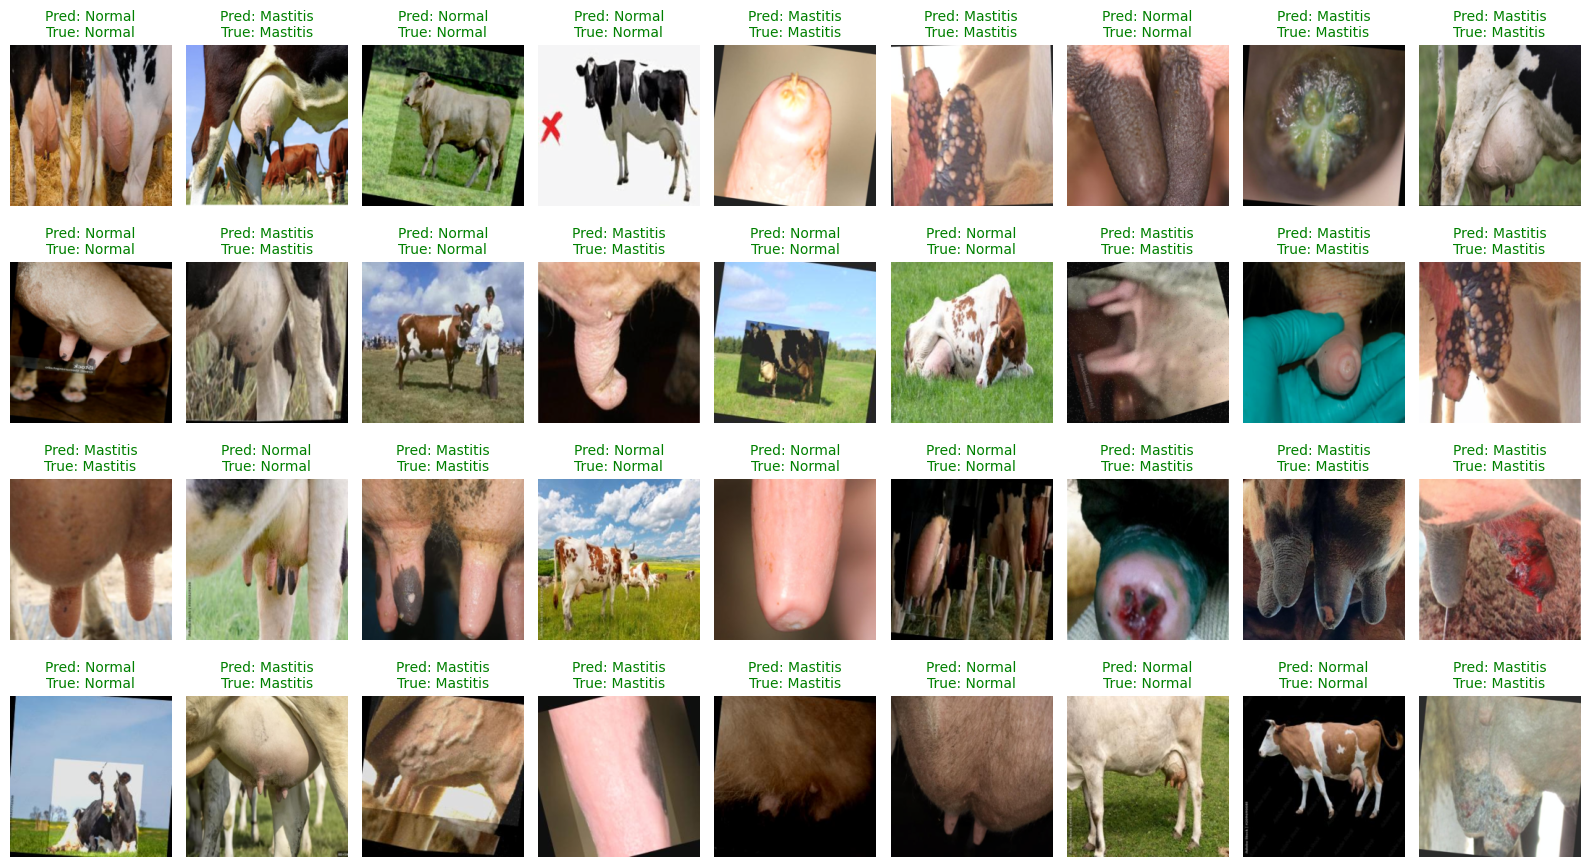

In [39]:
# Define class names based on your dataset
class_names = ["Normal", "Mastitis"]  # Adjust as needed

# Call the function to visualize all test images
visualize_all_test_images(model, test_loader, class_names)

# Ensure plots are displayed properly
plt.ioff()
plt.show()
